In [4]:
import pandas as pd
import numpy as np

DIEBOLD-MARIANO TESTS (α = 0.05)
Loaded all prediction files:
Total observations: 30
Date range: 2018-11-14 to 2018-12-28
Models: ['LSTM', 'XGBoost', 'ARIMA', 'ARIMA-LSTM', 'ARIMA-XGBoost', 'LSTM-XGBoost']

MODEL PERFORMANCE METRICS

Performance Metrics (sorted by RMSE):
--------------------------------------------------------------------------------
                     MSE     RMSE      MAE    MAPE  Mean_Residual  Std_Residual
XGBoost        4419.6452  66.4804  51.6370  1.6798       -28.2564       60.1766
ARIMA          4739.1138  68.8412  52.2214  1.6971       -25.2708       64.0351
ARIMA-XGBoost  4771.8539  69.0786  52.5432  1.7075       -26.1843       63.9237
ARIMA-LSTM     4777.0579  69.1163  52.5578  1.7074       -24.8558       64.4922
LSTM-XGBoost   5291.5957  72.7434  53.6240  1.7481       -40.0265       60.7410
LSTM           6644.1440  81.5116  59.7598  1.9491       -51.7966       62.9385

--------------------------------------------------------------------------------
Best 

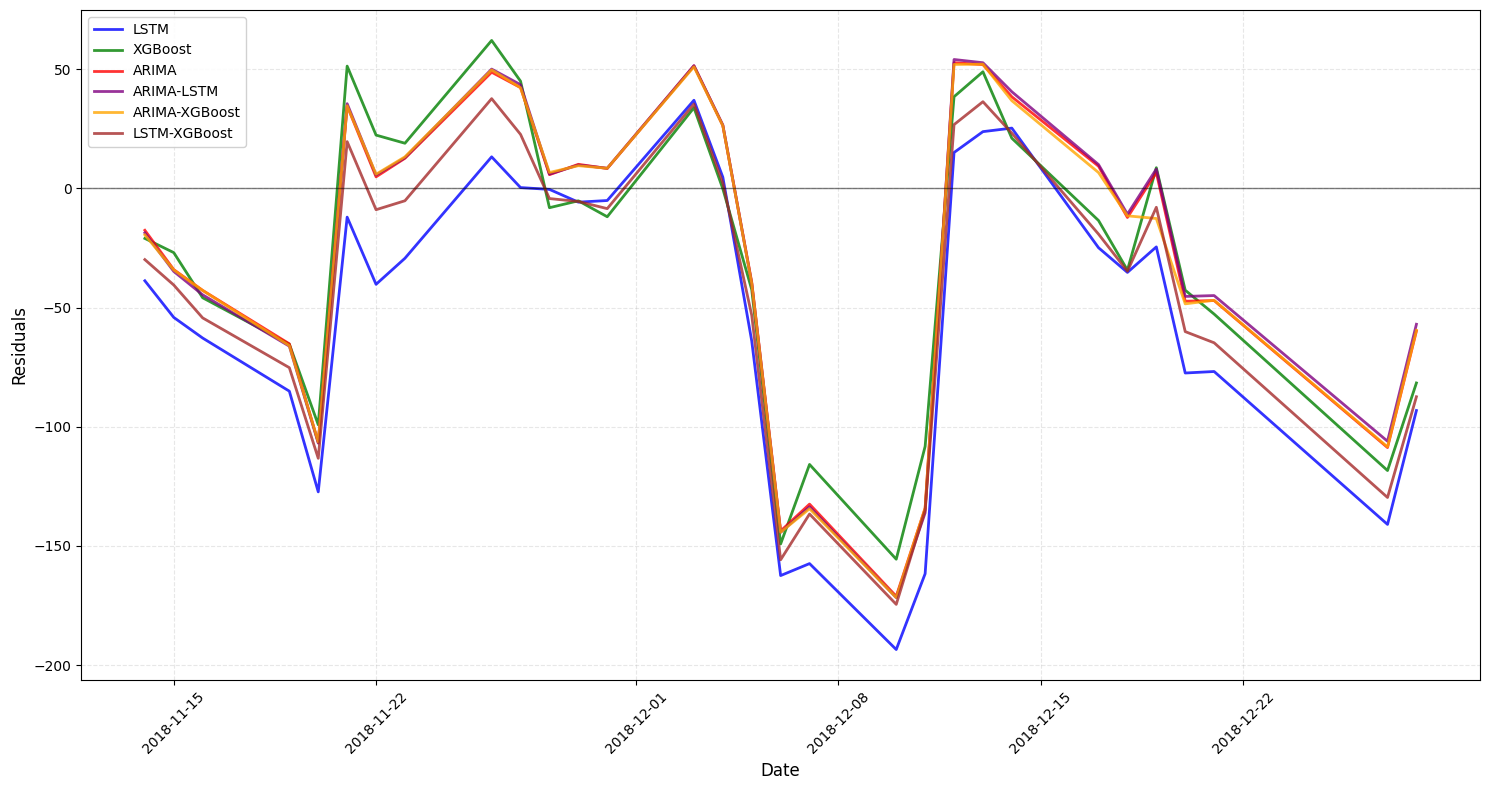


FINAL SUMMARY WITH CRITICAL VALUES (α = 0.05)

🏆 PERFORMANCE RANKING (Based on RMSE):
----------------------------------------
1. XGBoost: RMSE = 66.48, MAE = 51.64
2. ARIMA: RMSE = 68.84, MAE = 52.22
3. ARIMA-XGBoost: RMSE = 69.08, MAE = 52.54
4. ARIMA-LSTM: RMSE = 69.12, MAE = 52.56
5. LSTM-XGBoost: RMSE = 72.74, MAE = 53.62
6. LSTM: RMSE = 81.51, MAE = 59.76

🔍 STATISTICALLY SIGNIFICANT FINDINGS (α = 0.05):
----------------------------------------
Based on Squared Error Loss (MSE) - Critical value: |DM| > 1.960
  • XGBoost > LSTM-XGBoost (p < 0.05) (DM=-2.228)
  • XGBoost > LSTM (p < 0.01) (DM=-2.819)
  • ARIMA > LSTM (p < 0.01) (DM=-3.226)
  • ARIMA-XGBoost > LSTM (p < 0.01) (DM=-3.214)
  • ARIMA-LSTM > LSTM (p < 0.01) (DM=-3.148)
  • LSTM-XGBoost > LSTM (p < 0.01) (DM=-3.345)

Based on Absolute Error Loss (MAE) - Critical value: |DM| > 1.960
  • LSTM-XGBoost > LSTM (p < 0.05) (DM=-2.526)

📊 DIEBOLD-MARIANO TEST INTERPRETATION:
----------------------------------------
1. Significa

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Dict
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. LOAD ALL PREDICTION FILES
# ============================================

print("="*60)
print("DIEBOLD-MARIANO TESTS (α = 0.05)")
print("="*60)

# Load all CSV files
models_data = {
    'LSTM': pd.read_csv('lstm.csv', parse_dates=['Date']),
    'XGBoost': pd.read_csv('xgboost.csv', parse_dates=['Date']),
    'ARIMA': pd.read_csv('arima.csv', parse_dates=['Date']),
    'ARIMA-LSTM': pd.read_csv('arima_lstm.csv', parse_dates=['Date']),
    'ARIMA-XGBoost': pd.read_csv('arima_xgboost.csv', parse_dates=['Date']),
    'LSTM-XGBoost': pd.read_csv('lstm_xgboost.csv', parse_dates=['Date'])
}

# Standardize column names for consistency
for model_name, df in models_data.items():
    # Find the prediction column (non-Date, non-Actual)
    pred_col = [col for col in df.columns if col not in ['Date', 'Actual']][0]
    # Rename prediction column to standardized name
    df.rename(columns={pred_col: f'{model_name}_Predicted'}, inplace=True)

# Create a unified DataFrame with all predictions
unified_df = models_data['ARIMA'][['Date', 'Actual']].copy()

for model_name, df in models_data.items():
    pred_col = f'{model_name}_Predicted'
    unified_df[pred_col] = df[pred_col]

print("Loaded all prediction files:")
print(f"Total observations: {len(unified_df)}")
print(f"Date range: {unified_df['Date'].min().date()} to {unified_df['Date'].max().date()}")
print(f"Models: {list(models_data.keys())}")

# ============================================
# 2. CALCULATE RESIDUALS AND PERFORMANCE METRICS
# ============================================

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)

# Calculate residuals and performance metrics
metrics = {}
residuals_dict = {}

for model_name in models_data.keys():
    pred_col = f'{model_name}_Predicted'
    residuals = unified_df['Actual'] - unified_df[pred_col]
    residuals_dict[model_name] = residuals
    
    # Calculate metrics
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residuals))
    mape = np.mean(np.abs(residuals / unified_df['Actual'])) * 100
    
    metrics[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'Mean_Residual': np.mean(residuals),
        'Std_Residual': np.std(residuals)
    }

# Create performance DataFrame
metrics_df = pd.DataFrame(metrics).T
metrics_df = metrics_df.sort_values('RMSE')

print("\nPerformance Metrics (sorted by RMSE):")
print("-" * 80)
print(metrics_df.round(4).to_string())
print("\n" + "-" * 80)
print(f"Best model by RMSE: {metrics_df.index[0]} ({metrics_df.iloc[0]['RMSE']:.2f})")
print(f"Worst model by RMSE: {metrics_df.index[-1]} ({metrics_df.iloc[-1]['RMSE']:.2f})")

# ============================================
# 3. DIEBOLD-MARIANO TEST IMPLEMENTATION (α = 0.05)
# ============================================

def diebold_mariano_test(residuals1: pd.Series, residuals2: pd.Series, 
                        h: int = 1, loss_type: str = 'squared') -> Dict:
    """
    Perform Diebold-Mariano test for comparing two forecast models.
    
    Parameters:
    -----------
    residuals1 : pd.Series
        Residuals from model 1 (actual - predicted)
    residuals2 : pd.Series
        Residuals from model 2 (actual - predicted)
    h : int
        Forecast horizon (default=1 for one-step ahead)
    loss_type : str
        Loss function: 'squared' (MSE) or 'absolute' (MAE)
    
    Returns:
    --------
    dict : Test results including DM statistic and p-values
    """
    from scipy.stats import norm
    
    # Ensure equal length
    n = min(len(residuals1), len(residuals2))
    residuals1 = residuals1.iloc[:n]
    residuals2 = residuals2.iloc[:n]
    
    # Calculate loss differential
    if loss_type == 'squared':
        d = residuals1**2 - residuals2**2
    elif loss_type == 'absolute':
        d = np.abs(residuals1) - np.abs(residuals2)
    else:
        raise ValueError("loss_type must be 'squared' or 'absolute'")
    
    # Calculate mean and variance of loss differential
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)  # Sample variance
    
    # Calculate DM statistic
    dm_stat = mean_d / np.sqrt(var_d / n)
    
    # Calculate p-values (two-tailed test)
    p_value_two_tailed = 2 * (1 - norm.cdf(abs(dm_stat)))
    p_value_one_tailed_better = 1 - norm.cdf(dm_stat)  # H1: model2 better than model1
    p_value_one_tailed_worse = norm.cdf(dm_stat)       # H1: model2 worse than model1
    
    # Bartlett's small-sample correction
    bartlett_factor = 1 + (h - 1) / n
    dm_stat_corrected = dm_stat / np.sqrt(bartlett_factor)
    p_value_two_tailed_corrected = 2 * (1 - norm.cdf(abs(dm_stat_corrected)))
    
    return {
        'DM_Statistic': dm_stat,
        'DM_Statistic_Corrected': dm_stat_corrected,
        'P_Value_Two_Tailed': p_value_two_tailed,
        'P_Value_Two_Tailed_Corrected': p_value_two_tailed_corrected,
        'P_Value_One_Tailed_Better': p_value_one_tailed_better,
        'P_Value_One_Tailed_Worse': p_value_one_tailed_worse,
        'Mean_Loss_Differential': mean_d,
        'Std_Loss_Differential': np.sqrt(var_d),
        'Sample_Size': n,
        'Loss_Type': loss_type
    }

# ============================================
# 4. PERFORM PAIRWISE DIEBOLD-MARIANO TESTS (α = 0.05)
# ============================================

print("\n" + "="*80)
print("DIEBOLD-MARIANO TESTS - MODEL COMPARISONS (α = 0.05)")
print("="*80)

# Get model names in sorted order by RMSE (best to worst)
model_names_sorted = list(metrics_df.index)

# Perform pairwise DM tests
dm_results = {}
model_pairs = []

for i, model1 in enumerate(model_names_sorted):
    for model2 in model_names_sorted[i+1:]:
        pair_key = f"{model1} vs {model2}"
        model_pairs.append(pair_key)
        
        # Get residuals
        res1 = residuals_dict[model1]
        res2 = residuals_dict[model2]
        
        # Perform DM test with both loss functions
        dm_squared = diebold_mariano_test(res1, res2, h=1, loss_type='squared')
        dm_absolute = diebold_mariano_test(res1, res2, h=1, loss_type='absolute')
        
        dm_results[pair_key] = {
            'Squared_Error': dm_squared,
            'Absolute_Error': dm_absolute
        }

# ============================================
# 5. DISPLAY DM TEST RESULTS WITH CRITICAL VALUES
# ============================================

# Critical values for α = 0.05
critical_value_two_tailed = norm.ppf(1 - 0.05/2)  # ±1.96 for two-tailed
critical_value_one_tailed = norm.ppf(1 - 0.05)    # 1.645 for one-tailed

print("\n" + "="*80)
print("DIEBOLD-MARIANO TEST RESULTS (Squared Error Loss)")
print("="*80)
print("\nH₀: The two models have equal predictive accuracy")
print("H₁: The two models have different predictive accuracy")
print(f"Significance level: α = 0.05")
print(f"Critical values: ±{critical_value_two_tailed:.3f} (two-tailed), {critical_value_one_tailed:.3f} (one-tailed)")
print("\nDECISION RULE:")
print(f"- Reject H₀ if |DM Statistic| > {critical_value_two_tailed:.3f} (two-tailed)")
print(f"- Reject H₀ if DM Statistic > {critical_value_one_tailed:.3f} (model 2 better than model 1)")
print(f"- Reject H₀ if DM Statistic < -{critical_value_one_tailed:.3f} (model 1 better than model 2)\n")

print(f"{'Model Pair':<25} {'DM Stat':<10} {'P-Value':<12} {'Sig.':<8} {'Reject H₀?':<12} {'Conclusion':<30}")
print("-" * 107)

for pair in model_pairs:
    dm_info = dm_results[pair]['Squared_Error']
    dm_stat = dm_info['DM_Statistic_Corrected']
    p_value = dm_info['P_Value_Two_Tailed_Corrected']
    abs_dm_stat = abs(dm_stat)
    
    # Determine if we reject H₀
    reject_h0 = "YES" if abs_dm_stat > critical_value_two_tailed else "NO"
    
    # Determine significance (α = 0.05)
    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    else:
        sig = ""
    
    # Determine which model is better
    model1, model2 = pair.split(" vs ")
    mean_diff = dm_info['Mean_Loss_Differential']
    
    if mean_diff > 0:
        # Model1 has higher loss (worse) than Model2
        better_model = model2
        worse_model = model1
        conclusion = f"{model2} better than {model1}"
    else:
        # Model1 has lower loss (better) than Model2
        better_model = model1
        worse_model = model2
        conclusion = f"{model1} better than {model2}"
    
    # Only show conclusion if significant at 5% level (α = 0.05)
    if p_value >= 0.05:
        conclusion = "No significant difference"
    
    print(f"{pair:<25} {dm_stat:>8.3f} {p_value:>11.4f} {sig:^8} {reject_h0:^12} {conclusion:<30}")

print("\n" + "="*80)
print("DIEBOLD-MARIANO TEST RESULTS (Absolute Error Loss)")
print("="*80)
print("\nH₀: The two models have equal predictive accuracy")
print("H₁: The two models have different predictive accuracy")
print(f"Significance level: α = 0.05")
print(f"Critical values: ±{critical_value_two_tailed:.3f} (two-tailed), {critical_value_one_tailed:.3f} (one-tailed)")
print("\nDECISION RULE:")
print(f"- Reject H₀ if |DM Statistic| > {critical_value_two_tailed:.3f} (two-tailed)")
print(f"- Reject H₀ if DM Statistic > {critical_value_one_tailed:.3f} (model 2 better than model 1)")
print(f"- Reject H₀ if DM Statistic < -{critical_value_one_tailed:.3f} (model 1 better than model 2)\n")

print(f"{'Model Pair':<25} {'DM Stat':<10} {'P-Value':<12} {'Sig.':<8} {'Reject H₀?':<12} {'Conclusion':<30}")
print("-" * 107)

for pair in model_pairs:
    dm_info = dm_results[pair]['Absolute_Error']
    dm_stat = dm_info['DM_Statistic_Corrected']
    p_value = dm_info['P_Value_Two_Tailed_Corrected']
    abs_dm_stat = abs(dm_stat)
    
    # Determine if we reject H₀
    reject_h0 = "YES" if abs_dm_stat > critical_value_two_tailed else "NO"
    
    # Determine significance (α = 0.05)
    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    else:
        sig = ""
    
    # Determine which model is better
    model1, model2 = pair.split(" vs ")
    mean_diff = dm_info['Mean_Loss_Differential']
    
    if mean_diff > 0:
        # Model1 has higher loss (worse) than Model2
        better_model = model2
        worse_model = model1
        conclusion = f"{model2} better than {model1}"
    else:
        # Model1 has lower loss (better) than Model2
        better_model = model1
        worse_model = model2
        conclusion = f"{model1} better than {model2}"
    
    # Only show conclusion if significant at 5% level (α = 0.05)
    if p_value >= 0.05:
        conclusion = "No significant difference"
    
    print(f"{pair:<25} {dm_stat:>8.3f} {p_value:>11.4f} {sig:^8} {reject_h0:^12} {conclusion:<30}")

# ============================================
# 6. CREATE SUMMARY OF SIGNIFICANT DIFFERENCES (α = 0.05)
# ============================================

print("\n" + "="*80)
print("SUMMARY OF SIGNIFICANT DIFFERENCES (α = 0.05)")
print("="*80)
print(f"Critical value for rejection: |DM| > {critical_value_two_tailed:.3f}")

print("\nSIGNIFICANT DIFFERENCES (Squared Error Loss):")
print("-" * 60)

significant_pairs_squared = []
for pair in model_pairs:
    dm_stat = dm_results[pair]['Squared_Error']['DM_Statistic_Corrected']
    p_value = dm_results[pair]['Squared_Error']['P_Value_Two_Tailed_Corrected']
    if abs(dm_stat) > critical_value_two_tailed:  # Reject H₀
        model1, model2 = pair.split(" vs ")
        mean_diff = dm_results[pair]['Squared_Error']['Mean_Loss_Differential']
        
        if mean_diff > 0:
            better = model2
            worse = model1
        else:
            better = model1
            worse = model2
        
        significance = ""
        if p_value < 0.01:
            significance = "(p < 0.01)"
        else:
            significance = "(p < 0.05)"
        
        significant_pairs_squared.append((pair, better, worse, p_value, significance, dm_stat))
        print(f"  • {better} significantly better than {worse} {significance} |DM|={abs(dm_stat):.3f}")

if not significant_pairs_squared:
    print(f"  No significant differences found at α = 0.05 (|DM| > {critical_value_two_tailed:.3f})")

print("\nSIGNIFICANT DIFFERENCES (Absolute Error Loss):")
print("-" * 60)

significant_pairs_absolute = []
for pair in model_pairs:
    dm_stat = dm_results[pair]['Absolute_Error']['DM_Statistic_Corrected']
    p_value = dm_results[pair]['Absolute_Error']['P_Value_Two_Tailed_Corrected']
    if abs(dm_stat) > critical_value_two_tailed:  # Reject H₀
        model1, model2 = pair.split(" vs ")
        mean_diff = dm_results[pair]['Absolute_Error']['Mean_Loss_Differential']
        
        if mean_diff > 0:
            better = model2
            worse = model1
        else:
            better = model1
            worse = model2
        
        significance = ""
        if p_value < 0.01:
            significance = "(p < 0.01)"
        else:
            significance = "(p < 0.05)"
        
        significant_pairs_absolute.append((pair, better, worse, p_value, significance, dm_stat))
        print(f"  • {better} significantly better than {worse} {significance} |DM|={abs(dm_stat):.3f}")

if not significant_pairs_absolute:
    print(f"  No significant differences found at α = 0.05 (|DM| > {critical_value_two_tailed:.3f})")

# ============================================
# 7. RESIDUALS PLOT (ALL 6 MODELS)
# ============================================

print("\n" + "="*80)
print("RESIDUALS PLOT - ALL 6 MODELS")
print("="*80)

# Define color palette for models
model_colors = {
    'LSTM': 'blue',
    'XGBoost': 'green',
    'ARIMA': 'red',
    'ARIMA-LSTM': 'purple',
    'ARIMA-XGBoost': 'orange',
    'LSTM-XGBoost': 'brown'
}

# Define line styles for better differentiation
line_styles = {
    'LSTM': '-',
    'XGBoost': '-',
    'ARIMA': '-',
    'ARIMA-LSTM': '-',
    'ARIMA-XGBoost': '-',
    'LSTM-XGBoost': '-'
}

# Create figure
plt.figure(figsize=(15, 8))

# Plot each model's residuals
for model_name, residuals in residuals_dict.items():
    plt.plot(unified_df['Date'], residuals, 
             label=model_name, 
             color=model_colors[model_name],
             linestyle=line_styles[model_name],
             linewidth=2,
             alpha=0.8)

# Add zero reference line
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Customize plot
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residuals', fontsize=12)

# Τοποθετούμε το legend μέσα στο plot
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Rotate date labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.show()

# ============================================
# 8. FINAL SUMMARY WITH CRITICAL VALUES
# ============================================

print("\n" + "="*80)
print("FINAL SUMMARY WITH CRITICAL VALUES (α = 0.05)")
print("="*80)

print("\n🏆 PERFORMANCE RANKING (Based on RMSE):")
print("-" * 40)
for i, (model_name, row) in enumerate(metrics_df.iterrows(), 1):
    print(f"{i}. {model_name}: RMSE = {row['RMSE']:.2f}, MAE = {row['MAE']:.2f}")

print("\n🔍 STATISTICALLY SIGNIFICANT FINDINGS (α = 0.05):")
print("-" * 40)

if significant_pairs_squared:
    print(f"Based on Squared Error Loss (MSE) - Critical value: |DM| > {critical_value_two_tailed:.3f}")
    for pair, better, worse, p_val, sig, dm_stat in significant_pairs_squared:
        print(f"  • {better} > {worse} {sig} (DM={dm_stat:.3f})")
else:
    print(f"No statistically significant differences found with squared error loss (|DM| > {critical_value_two_tailed:.3f})")

if significant_pairs_absolute:
    print(f"\nBased on Absolute Error Loss (MAE) - Critical value: |DM| > {critical_value_two_tailed:.3f}")
    for pair, better, worse, p_val, sig, dm_stat in significant_pairs_absolute:
        print(f"  • {better} > {worse} {sig} (DM={dm_stat:.3f})")
else:
    print(f"No statistically significant differences found with absolute error loss (|DM| > {critical_value_two_tailed:.3f})")

print("\n📊 DIEBOLD-MARIANO TEST INTERPRETATION:")
print("-" * 40)
print(f"1. Significance level: α = 0.05")
print(f"2. Critical values for rejection:")
print(f"   • Two-tailed test: |DM| > {critical_value_two_tailed:.3f}")
print(f"   • One-tailed test (right): DM > {critical_value_one_tailed:.3f}")
print(f"   • One-tailed test (left): DM < -{critical_value_one_tailed:.3f}")
print(f"3. *** indicates p < 0.01 (99% confidence)")
print(f"4. ** indicates p < 0.05 (95% confidence)")
print(f"5. No asterisk means not statistically significant")
print(f"6. 'Model A better than Model B' means Model A has significantly lower errors")

print("\n📈 DECISION RULES SUMMARY:")
print("-" * 40)
print("• For two-tailed test (H₁: models have different accuracy):")
print(f"  - Reject H₀ if |DM Statistic| > {critical_value_two_tailed:.3f}")
print("• For one-tailed test (H₁: model 2 is better than model 1):")
print(f"  - Reject H₀ if DM Statistic > {critical_value_one_tailed:.3f}")
print("• For one-tailed test (H₁: model 1 is better than model 2):")
print(f"  - Reject H₀ if DM Statistic < -{critical_value_one_tailed:.3f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)